In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
prefix = "../data/processed/"

In [33]:
#RP data sets have regular games and playoff games 
df_r = (pd.read_csv(prefix + "TeamStatisticsFrom2010RP.csv")).dropna()
df_m = (pd.read_csv(prefix + "TeamStatisticsFrom2010RegMatchups.csv")).dropna()

In [34]:
df_t = (pd.read_csv(prefix + "TeamStatisticsFrom2010Reg.csv")).dropna()

In [35]:
fea_raw_r = ['home', 'teamScore', 'fieldGoalsPercentage',
       'threePointersPercentage', 'freeThrowsPercentage',
       'reboundsOffensive', 'reboundsDefensive',
       'assists', 'turnovers', 'steals', 'blocks',
       'plusMinusPoints', 'win']

for col in fea_raw_r:
    df_t[f'{col}_ewm'] = (
        df_t.groupby('teamId')[col]
        .transform(lambda x: x.ewm(halflife=3).mean())
    )

In [36]:
matchup_recent = df_t.merge(
    df_t,
    on='gameId',
    suffixes=('_home', '_away')
)

# Keep only the home team's perspective (home == 1) to avoid mirrored duplicates
matchup_recent = matchup_recent[matchup_recent['home_home'] == 1]
matchup_recent = matchup_recent[matchup_recent['teamId_home'] != matchup_recent['teamId_away']]

'''
new_names = {}

for col in matchup_recent.columns:
    if 'home' in col:
        new_names[col] = 'home_' + col.replace('_home', '')
    if 'away' in col:
        new_names[col] = 'away_' + col.replace('_away', '')
    if 'win' in col:
        new_names[col] = 'win'

# Rename all at once
matchup_recent.rename(columns=new_names, inplace=True)
'''

"\nnew_names = {}\n\nfor col in matchup_recent.columns:\n    if 'home' in col:\n        new_names[col] = 'home_' + col.replace('_home', '')\n    if 'away' in col:\n        new_names[col] = 'away_' + col.replace('_away', '')\n    if 'win' in col:\n        new_names[col] = 'win'\n\n# Rename all at once\nmatchup_recent.rename(columns=new_names, inplace=True)\n"

In [30]:
for col in matchup_recent.columns:
    if 'home' in col:print(col)

home_gameDate
home_season
home_teamId
home_teamName
home_opponentTeamId
home_opponentTeamName
home_home
home_teamScore
home_opponentScore
home_fieldGoalsPercentage
home_threePointersPercentage
home_freeThrowsPercentage
home_reboundsOffensive
home_reboundsDefensive
home_assists
home_turnovers
home_steals
home_blocks
home_plusMinusPoints
home_rest_days
home_b2b
home_home_ewm
home_teamScore_ewm
home_fieldGoalsPercentage_ewm
home_threePointersPercentage_ewm
home_freeThrowsPercentage_ewm
home_reboundsOffensive_ewm
home_reboundsDefensive_ewm
home_assists_ewm
home_turnovers_ewm
home_steals_ewm
home_blocks_ewm
home_plusMinusPoints_ewm
away_home
away_home_ewm


In [37]:
diff_cols = []
for col in fea_raw_r: 
    diff_name = f'{col}_ewm_diff'
    matchup_recent[diff_name] = matchup_recent[f'{col}_ewm_home'] - matchup_recent[f'{col}_ewm_away']
    diff_cols.append(diff_name)

In [7]:

lllll = matchup_recent.columns
for v in lllll:
    if 'win' in v: print(v)
print(len(matchup_recent), len(df_t))

matchup_recent = matchup_recent.dropna()

win_home
win_ewm_home
win_away
win_ewm_away
win_ewm_diff
19132 38279


In [38]:
diff_cols2 = diff_cols + ['plusMinusPoints_ewm_away', 'turnovers_ewm_home']
xg_tr, xg_te, yg_tr, yg_te = train_test_split(matchup_recent[diff_cols2], matchup_recent['win_home'], random_state=17, test_size=0.2)
x_cv, xh, y_cv, yh = train_test_split(xg_tr, yg_tr, random_state=99, test_size= 0.5)

In [39]:
#Naive Bayes using ewm variables that we would have access to before a prediction 
#Reg data set
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

#Loop that iterates over each column in the above list, fits, and calculates the accuracy
#Only models/variables that yield results better than chance are reported

pipe_n = Pipeline(steps=[
    ('scale', StandardScaler()),
    ('svc', SVC())
])

pipe_n.fit(x_cv[diff_cols], y_cv)
y_pred = pipe_n.predict(xh[diff_cols])
acc    = 1.0*sum(y_pred==yh) / len(y_pred)
print(acc)

0.8690709525676206


In [10]:
#Naive Bayes using ewm variables that we would have access to before a prediction 
#Reg data set
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import roc_auc_score, precision_score
from sklearn.preprocessing import PolynomialFeatures

#Loop that iterates over each column in the above list, fits, and calculates the accuracy
#Only models/variables that yield results better than chance are reported

pipe_n = Pipeline(steps=[
    ('nb', GaussianNB())
])

pipe_n.fit(x_cv[diff_cols], y_cv)
y_pred = pipe_n.predict(xh[diff_cols])
acc    = 1.0*sum(y_pred==yh) / len(y_pred)
print(acc)

0.825297269044819


In [18]:
for col in matchup_recent.columns:
    if 'plus'in col: print(col)

plusMinusPoints_home
plusMinusPoints_ewm_home
plusMinusPoints_away
plusMinusPoints_ewm_away
plusMinusPoints_ewm_diff


In [40]:
#PyGAM initialization 
import scipy.sparse

def to_array(self):
    return self.toarray()

scipy.sparse.spmatrix.A = property(to_array)

# Generalized Additive Model (GAM):
# LinearGAM fits y ≈ sum_j f_j(x_j), where each f_j is a smooth curve.
from pygam import LogisticGAM, f, s, l, te
nsp = 20

v3 = ['fieldGoalsPercentage_ewm_diff','plusMinusPoints_ewm_diff', 'plusMinusPoints_ewm_away', 'fieldGoalsPercentage_ewm_diff', 'turnovers_ewm_home']

pipe_g = Pipeline(steps=[
    ('scale', StandardScaler()),
    ('gam', LogisticGAM(
        s(0, 100) + l(1) + l(2) + s(3) + l(4) + te(0,1), max_iter=300, 
        #s(0, 100) + l(1) + l(2) + s(3, 100) + l(4) + te(1,2) + te(1,4) + te(2,4) + te(3,4), max_iter=300, 
        ))
])
pipe_g.fit(x_cv[v3],y_cv)

#scores_dict = pipe_g['gam'].gridsearch(xh[v0], yh, lam = l_ary, return_scores=True)

#for model, score in scores_dict.items():
#    print(f"Lambda for spline: {model.lam[1]}, Score: {score}")

print(pipe_g['gam'].accuracy(xh[v3],yh))

0.7935450150267869


In [3]:
#Raw features

fea_raw_r = ['home', 'teamScore_roll10', 'fieldGoalsPercentage_roll10',
       'threePointersPercentage_roll10', 'freeThrowsPercentage_roll10',
       'reboundsOffensive_roll10', 'reboundsDefensive_roll10',
       'assists_roll10', 'turnovers_roll10', 'steals_roll10', 'blocks_roll10',
       'plusMinusPoints_roll10', 'win_roll10']

fea_raw_m = [ 'home_teamScore_roll10',
       'home_fieldGoalsPercentage_roll10',
       'home_threePointersPercentage_roll10',
       'home_freeThrowsPercentage_roll10', 'home_reboundsOffensive_roll10',
       'home_reboundsDefensive_roll10', 'home_assists_roll10',
       'home_turnovers_roll10', 'home_steals_roll10', 'home_blocks_roll10',
       'home_plusMinusPoints_roll10', 'home_win_roll10', 'away_teamScore_roll10', 'away_fieldGoalsPercentage_roll10',
       'away_threePointersPercentage_roll10',
       'away_freeThrowsPercentage_roll10', 'away_reboundsOffensive_roll10',
       'away_reboundsDefensive_roll10', 'away_assists_roll10',
       'away_turnovers_roll10', 'away_steals_roll10', 'away_blocks_roll10',
       'away_plusMinusPoints_roll10', 'away_win_roll10',
       'teamScore_roll10_diff', 'fieldGoalsPercentage_roll10_diff',
       'threePointersPercentage_roll10_diff',
       'freeThrowsPercentage_roll10_diff', 'reboundsOffensive_roll10_diff',
       'reboundsDefensive_roll10_diff', 'assists_roll10_diff',
       'turnovers_roll10_diff', 'steals_roll10_diff', 'blocks_roll10_diff',
       'plusMinusPoints_roll10_diff', 'win_roll10_diff']

print('Im done')

Im done


In [36]:
#Using Logistic Regression with Lasso and RandomForest Classifier feature importance
#to find the best features
#Creating the train sets
xr_fea_tr, xr_fea_te, yr_fea_tr, yr_fea_te = train_test_split(df_r[fea_raw_r], df_r['win'], random_state=17, test_size=0.25)
xm_fea_tr, xm_fea_te, ym_fea_tr, ym_fea_te = train_test_split(df_m[fea_raw_m], df_m['win'], random_state=19, test_size=0.25)


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pipe_lr = Pipeline(steps=[
    ('scale', StandardScaler()),
    ('logr', LogisticRegression(solver='liblinear', penalty='l1'))
])

pipe_rf = Pipeline(steps=[
    ('scale', StandardScaler()),
    ('ranf', RandomForestClassifier(criterion='entropy'))
])

In [47]:
pipe_lr.fit(xr_fea_tr,yr_fea_tr)
pipe_rf.fit(xr_fea_tr,yr_fea_tr)

/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('ranf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [49]:
print(pipe_lr.score(xr_fea_tr,yr_fea_tr), pipe_rf.score(xr_fea_tr,yr_fea_tr))

0.61064307321992 1.0


In [50]:
lr_coef = pipe_lr['logr'].coef_
for name, coef in zip(fea_raw_r, lr_coef[0]):
    print(('%s %.3f')%(name, coef))

home 0.328
teamScore_roll10 0.007
fieldGoalsPercentage_roll10 -0.003
threePointersPercentage_roll10 -0.040
freeThrowsPercentage_roll10 -0.000
reboundsOffensive_roll10 -0.048
reboundsDefensive_roll10 -0.024
assists_roll10 0.009
turnovers_roll10 -0.018
steals_roll10 -0.001
blocks_roll10 0.029
plusMinusPoints_roll10 0.413
win_roll10 0.058


In [51]:
rf_coef = pipe_rf['ranf'].feature_importances_
for name, coef in zip(fea_raw_r, rf_coef):
    print(('%s %.3f')%(name, coef))

home 0.019
teamScore_roll10 0.088
fieldGoalsPercentage_roll10 0.093
threePointersPercentage_roll10 0.092
freeThrowsPercentage_roll10 0.093
reboundsOffensive_roll10 0.080
reboundsDefensive_roll10 0.082
assists_roll10 0.083
turnovers_roll10 0.080
steals_roll10 0.077
blocks_roll10 0.075
plusMinusPoints_roll10 0.101
win_roll10 0.036


In [52]:
pipe_lr.fit(xm_fea_tr,ym_fea_tr)
pipe_rf.fit(xm_fea_tr,ym_fea_tr)

/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('ranf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [53]:
print(pipe_lr.score(xm_fea_tr,ym_fea_tr), pipe_rf.score(xm_fea_tr,ym_fea_tr))

0.6353821138211382 1.0


In [55]:
lr_coef = pipe_lr['logr'].coef_
for name, coef in zip(fea_raw_m, lr_coef[0]):
    print(('%s %.3f')%(name, coef))

home_teamScore_roll10 -0.063
home_fieldGoalsPercentage_roll10 0.073
home_threePointersPercentage_roll10 0.000
home_freeThrowsPercentage_roll10 0.021
home_reboundsOffensive_roll10 0.000
home_reboundsDefensive_roll10 0.000
home_assists_roll10 -0.023
home_turnovers_roll10 -0.001
home_steals_roll10 0.006
home_blocks_roll10 0.003
home_plusMinusPoints_roll10 0.071
home_win_roll10 0.000
away_teamScore_roll10 -0.027
away_fieldGoalsPercentage_roll10 0.000
away_threePointersPercentage_roll10 0.002
away_freeThrowsPercentage_roll10 0.001
away_reboundsOffensive_roll10 0.045
away_reboundsDefensive_roll10 0.033
away_assists_roll10 -0.037
away_turnovers_roll10 0.000
away_steals_roll10 0.011
away_blocks_roll10 0.000
away_plusMinusPoints_roll10 0.000
away_win_roll10 -0.024
teamScore_roll10_diff 0.000
fieldGoalsPercentage_roll10_diff 0.003
threePointersPercentage_roll10_diff -0.048
freeThrowsPercentage_roll10_diff 0.000
reboundsOffensive_roll10_diff -0.018
reboundsDefensive_roll10_diff -0.009
assists_rol

In [56]:
rf_coef = pipe_rf['ranf'].feature_importances_
for name, coef in zip(fea_raw_m, rf_coef):
    print(('%s %.3f')%(name, coef))

home_teamScore_roll10 0.027
home_fieldGoalsPercentage_roll10 0.030
home_threePointersPercentage_roll10 0.030
home_freeThrowsPercentage_roll10 0.029
home_reboundsOffensive_roll10 0.027
home_reboundsDefensive_roll10 0.027
home_assists_roll10 0.027
home_turnovers_roll10 0.026
home_steals_roll10 0.025
home_blocks_roll10 0.025
home_plusMinusPoints_roll10 0.038
home_win_roll10 0.016
away_teamScore_roll10 0.028
away_fieldGoalsPercentage_roll10 0.030
away_threePointersPercentage_roll10 0.030
away_freeThrowsPercentage_roll10 0.029
away_reboundsOffensive_roll10 0.025
away_reboundsDefensive_roll10 0.026
away_assists_roll10 0.027
away_turnovers_roll10 0.026
away_steals_roll10 0.025
away_blocks_roll10 0.024
away_plusMinusPoints_roll10 0.032
away_win_roll10 0.015
teamScore_roll10_diff 0.030
fieldGoalsPercentage_roll10_diff 0.032
threePointersPercentage_roll10_diff 0.030
freeThrowsPercentage_roll10_diff 0.030
reboundsOffensive_roll10_diff 0.027
reboundsDefensive_roll10_diff 0.026
assists_roll10_diff 

/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


0.6353821138211382

In [72]:
from sklearn.preprocessing import PowerTransformer
pipe_lrs = Pipeline(steps=[
    ('scale', StandardScaler()),
    ('logr', LogisticRegression(solver='liblinear', penalty='l1'))
])
tmpl = list(xm_fea_tr.columns)
tmpl.remove('plusMinusPoints_roll10_diff')
pipe_lrs.fit(xm_fea_tr[tmpl],ym_fea_tr)

print(pipe_lrs.score(xm_fea_tr[tmpl],ym_fea_tr))

lr_coef = pipe_lrs['logr'].coef_
for name, coef in zip(tmpl, lr_coef[0]):
    print(('%s %.3f')%(name, coef))

/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


0.6355121951219512
home_teamScore_roll10 -0.063
home_fieldGoalsPercentage_roll10 0.072
home_threePointersPercentage_roll10 0.000
home_freeThrowsPercentage_roll10 0.021
home_reboundsOffensive_roll10 0.000
home_reboundsDefensive_roll10 0.000
home_assists_roll10 -0.023
home_turnovers_roll10 -0.001
home_steals_roll10 0.006
home_blocks_roll10 0.003
home_plusMinusPoints_roll10 0.438
home_win_roll10 0.000
away_teamScore_roll10 -0.027
away_fieldGoalsPercentage_roll10 0.000
away_threePointersPercentage_roll10 0.002
away_freeThrowsPercentage_roll10 0.001
away_reboundsOffensive_roll10 0.045
away_reboundsDefensive_roll10 0.032
away_assists_roll10 -0.037
away_turnovers_roll10 0.000
away_steals_roll10 0.011
away_blocks_roll10 0.000
away_plusMinusPoints_roll10 -0.370
away_win_roll10 -0.025
teamScore_roll10_diff 0.000
fieldGoalsPercentage_roll10_diff 0.004
threePointersPercentage_roll10_diff -0.048
freeThrowsPercentage_roll10_diff 0.000
reboundsOffensive_roll10_diff -0.018
reboundsDefensive_roll10_dif

In [71]:
xm_fea_tr.columns

Index(['home_teamScore_roll10', 'home_fieldGoalsPercentage_roll10',
       'home_threePointersPercentage_roll10',
       'home_freeThrowsPercentage_roll10', 'home_reboundsOffensive_roll10',
       'home_reboundsDefensive_roll10', 'home_assists_roll10',
       'home_turnovers_roll10', 'home_steals_roll10', 'home_blocks_roll10',
       'home_plusMinusPoints_roll10', 'home_win_roll10',
       'away_teamScore_roll10', 'away_fieldGoalsPercentage_roll10',
       'away_threePointersPercentage_roll10',
       'away_freeThrowsPercentage_roll10', 'away_reboundsOffensive_roll10',
       'away_reboundsDefensive_roll10', 'away_assists_roll10',
       'away_turnovers_roll10', 'away_steals_roll10', 'away_blocks_roll10',
       'away_plusMinusPoints_roll10', 'away_win_roll10',
       'teamScore_roll10_diff', 'fieldGoalsPercentage_roll10_diff',
       'threePointersPercentage_roll10_diff',
       'freeThrowsPercentage_roll10_diff', 'reboundsOffensive_roll10_diff',
       'reboundsDefensive_roll10_diff'

In [76]:
pipe_lrs = Pipeline(steps=[
    ('scale', StandardScaler()),
    ('logr', LogisticRegression(solver='liblinear', penalty='l1'))
])
tmpl = list(xm_fea_tr.columns)

tmpl.remove('plusMinusPoints_roll10_diff')
tmpl.remove('home_plusMinusPoints_roll10')
tmpl.remove('away_plusMinusPoints_roll10')
pipe_lrs.fit(xm_fea_tr[tmpl],ym_fea_tr)
varlist = ['plusMinusPoints_roll10_diff', 'home_plusMinusPoints_roll10','away_plusMinusPoints_roll10']
print(pipe_lrs.score(xm_fea_tr[tmpl],ym_fea_tr))
lr_coef = pipe_lrs['logr'].coef_
for name, coef in zip(tmpl, lr_coef[0]):
    if abs(coef) >=0.1:
        varlist.append(name)
    else:
        print(('%s %.3f')%(name, coef))

/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


0.6315447154471545
home_teamScore_roll10 -0.073
home_threePointersPercentage_roll10 0.008
home_freeThrowsPercentage_roll10 0.032
home_reboundsOffensive_roll10 0.041
home_reboundsDefensive_roll10 0.049
home_assists_roll10 -0.039
home_turnovers_roll10 -0.009
home_steals_roll10 0.028
home_blocks_roll10 0.002
away_teamScore_roll10 -0.032
away_fieldGoalsPercentage_roll10 0.000
away_threePointersPercentage_roll10 0.000
away_freeThrowsPercentage_roll10 0.000
away_reboundsOffensive_roll10 0.015
away_reboundsDefensive_roll10 0.000
away_assists_roll10 -0.028
away_turnovers_roll10 0.000
away_steals_roll10 0.000
away_blocks_roll10 0.000
teamScore_roll10_diff 0.000
threePointersPercentage_roll10_diff 0.002
freeThrowsPercentage_roll10_diff 0.028
reboundsOffensive_roll10_diff 0.000
reboundsDefensive_roll10_diff 0.066
assists_roll10_diff 0.000
steals_roll10_diff 0.060
blocks_roll10_diff 0.038


In [77]:
pipe_lrs = Pipeline(steps=[
    ('scale', StandardScaler()),
    ('logr', LogisticRegression(solver='liblinear', penalty='l1'))
])
tmpl = list(xm_fea_tr.columns)

for var in varlist:
    tmpl.remove(var)

pipe_lrs.fit(xm_fea_tr[tmpl],ym_fea_tr)

print(pipe_lrs.score(xm_fea_tr[tmpl],ym_fea_tr))
lr_coef = pipe_lrs['logr'].coef_
for name, coef in zip(tmpl, lr_coef[0]):
    if abs(coef) >=0.1:
        varlist.append(name)
    else:
        print(('%s %.3f')%(name, coef))

/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


0.6143739837398374
home_teamScore_roll10 0.030
home_threePointersPercentage_roll10 0.080
home_freeThrowsPercentage_roll10 0.013
home_reboundsOffensive_roll10 0.000
home_reboundsDefensive_roll10 0.000
home_assists_roll10 -0.007
home_steals_roll10 0.011
home_blocks_roll10 0.036
away_teamScore_roll10 0.000
away_threePointersPercentage_roll10 0.000
away_freeThrowsPercentage_roll10 0.000
away_reboundsOffensive_roll10 -0.006
away_reboundsDefensive_roll10 -0.007
away_assists_roll10 -0.020
away_steals_roll10 0.000
away_blocks_roll10 0.000
teamScore_roll10_diff 0.091
threePointersPercentage_roll10_diff 0.061
freeThrowsPercentage_roll10_diff 0.066
reboundsOffensive_roll10_diff 0.001
assists_roll10_diff 0.000
blocks_roll10_diff 0.053


In [4]:
varlist

NameError: name 'varlist' is not defined

In [82]:
corr = xm_fea_tr[varlist].corr()
corr

,plusMinusPoints_roll10_diff,home_plusMinusPoints_roll10,away_plusMinusPoints_roll10,home_fieldGoalsPercentage_roll10,home_win_roll10,away_win_roll10,fieldGoalsPercentage_roll10_diff,turnovers_roll10_diff,win_roll10_diff,home_turnovers_roll10,away_fieldGoalsPercentage_roll10,away_turnovers_roll10,reboundsDefensive_roll10_diff,steals_roll10_diff
plusMinusPoints_roll10_diff,1.000000,0.698198,-0.706881,0.380474,0.611508,-0.620122,0.587991,-0.251512,0.877058,-0.169193,-0.387163,0.168584,0.441986,0.180094
home_plusMinusPoints_roll10,0.698198,1.000000,0.012840,0.548321,0.881974,0.020362,0.411203,-0.178920,0.610687,-0.255015,0.010127,-0.013641,0.311798,0.127935
away_plusMinusPoints_roll10,-0.706881,0.012840,1.000000,0.010340,0.017308,0.886254,-0.414979,0.174513,-0.621629,-0.015647,0.550764,-0.248942,-0.309265,-0.125137
home_fieldGoalsPercentage_roll10,0.380474,0.548321,0.010340,1.000000,0.502257,0.016810,0.650652,-0.019304,0.344037,-0.119107,0.147772,-0.092326,0.098122,0.041015
home_win_roll10,0.611508,0.881974,0.017308,0.502257,1.000000,0.013965,0.375504,-0.161794,0.698933,-0.234450,0.010779,-0.016149,0.283780,0.100853
away_win_roll10,-0.620122,0.020362,0.886254,0.016810,0.013965,1.000000,-0.377079,0.149550,-0.705356,-0.022111,0.507842,-0.221964,-0.275878,-0.107447
fieldGoalsPercentage_roll10_diff,0.587991,0.411203,-0.414979,0.650652,0.375504,-0.377079,1.000000,-0.033532,0.535912,-0.021899,-0.654891,0.023130,0.150108,0.064469
turnovers_roll10_diff,-0.251512,-0.178920,0.174513,-0.019304,-0.161794,0.149550,-0.033532,1.000000,-0.221666,0.668160,0.024462,-0.674788,0.102875,0.082059
win_roll10_diff,0.877058,0.610687,-0.621629,0.344037,0.698933,-0.705356,0.535912,-0.221666,1.000000,-0.150392,-0.355596,0.147313,0.398501,0.148349
home_turnovers_roll10,-0.169193,-0.255015,-0.015647,-0.119107,-0.234450,-0.022111,-0.021899,0.668160,-0.150392,1.000000,-0.090013,0.098228,0.063056,0.060287


In [4]:
#PyGAM initialization 
import scipy.sparse

def to_array(self):
    return self.toarray()

scipy.sparse.spmatrix.A = property(to_array)

# Generalized Additive Model (GAM):
# LinearGAM fits y ≈ sum_j f_j(x_j), where each f_j is a smooth curve.
from pygam import LogisticGAM, f, s, l

In [5]:
varlist = ['plusMinusPoints_roll10_diff',
 'home_plusMinusPoints_roll10',
 'away_plusMinusPoints_roll10',
 'home_fieldGoalsPercentage_roll10',
 'home_win_roll10',
 'away_win_roll10',
 'fieldGoalsPercentage_roll10_diff',
 'turnovers_roll10_diff',
 'win_roll10_diff',
 'home_turnovers_roll10',
 'away_fieldGoalsPercentage_roll10',
 'away_turnovers_roll10',
 'reboundsDefensive_roll10_diff',
 'steals_roll10_diff']

In [ ]:
#Test train split for gams
var_1st_4 = varlist[:6]
xg_tr, xg_te, yg_tr, yg_te = train_test_split(df_m[varlist], df_m['win'], random_state=17, test_size=0.2)
x_cv, xh, y_cv, yh = train_test_split(xg_tr, yg_tr, random_state=99, test_size= 0.5)

In [70]:
x_cv, xh, y_cv, yh = train_test_split(xg_tr, yg_tr, random_state=99, test_size= 0.5)

In [9]:
from itertools import combinations

combo5 = list(combinations(varlist, 5))

In [43]:
combo5[0]

('plusMinusPoints_roll10_diff',
 'home_plusMinusPoints_roll10',
 'away_plusMinusPoints_roll10',
 'home_fieldGoalsPercentage_roll10',
 'home_win_roll10')

In [16]:
pipe_g = Pipeline(steps=[
    #('poly', PolynomialFeatures(2)),
    ('scale', StandardScaler()),
    ('gam', LogisticGAM(
        l(0) + l(1) + l(2) + l(3) + l(4), max_iter=250
        ))
])


In [62]:
len(combo5)
count = 0

In [17]:
res = []
for count, vars in enumerate(combo5):
    vars = list(vars)
    pipe_g.fit(x_cv[vars], y_cv)
    res.append([count,pipe_g['gam'].loglikelihood(xh[vars],yh)])
    if count % 50 ==0: print(count)

0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400
1450
1500
1550
1600
1650
1700
1750
1800
1850
1900
1950
2000


In [10]:
print(res[0][1])

-10680.626218751091


In [33]:
ll_res = [x[1] for x in res]
ls = np.array(ll_res)

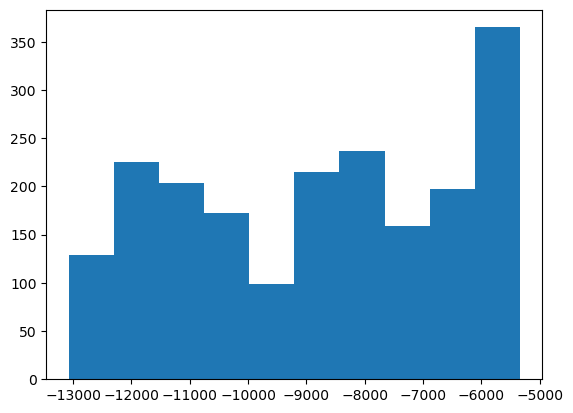

In [19]:
fig = plt.hist(l)
plt.show()

In [34]:
print(ls.mean(), ls.std())

-8792.409032471714 2348.2584759744796


In [21]:
best_holder = []
for val in res:
    if val[1] < -12800:
        print(combo5[val[0]])
        best_holder.append(combo5[val[0]])

('plusMinusPoints_roll10_diff', 'away_plusMinusPoints_roll10', 'home_fieldGoalsPercentage_roll10', 'fieldGoalsPercentage_roll10_diff', 'home_turnovers_roll10')
('plusMinusPoints_roll10_diff', 'away_plusMinusPoints_roll10', 'home_fieldGoalsPercentage_roll10', 'home_turnovers_roll10', 'away_fieldGoalsPercentage_roll10')
('plusMinusPoints_roll10_diff', 'away_plusMinusPoints_roll10', 'home_fieldGoalsPercentage_roll10', 'home_turnovers_roll10', 'reboundsDefensive_roll10_diff')
('plusMinusPoints_roll10_diff', 'away_plusMinusPoints_roll10', 'home_fieldGoalsPercentage_roll10', 'home_turnovers_roll10', 'steals_roll10_diff')
('plusMinusPoints_roll10_diff', 'away_plusMinusPoints_roll10', 'home_fieldGoalsPercentage_roll10', 'reboundsDefensive_roll10_diff', 'steals_roll10_diff')
('plusMinusPoints_roll10_diff', 'away_plusMinusPoints_roll10', 'fieldGoalsPercentage_roll10_diff', 'home_turnovers_roll10', 'away_fieldGoalsPercentage_roll10')
('plusMinusPoints_roll10_diff', 'away_plusMinusPoints_roll10', 

In [35]:
l_sort = sorted(ls)
print(l_sort[0], l_sort[len(l_sort) -1])

l_median = l_sort[int(0.5*len(l_sort))]
lfifth = int(0.2*len(l_sort))
l20, l40, l60, l80 = l_sort[lfifth], l_sort[2*lfifth], l_sort[3*lfifth], l_sort[4*lfifth]
print(l_median)
print(l20, l40, l60, l80)

-13070.608062517229 -5342.876571246155
-8533.919979940583
-11297.861545661824 -9370.188321233312 -8044.2719087348705 -6253.610650647796


In [23]:
l_top_50 = []
l_top_40 = []
l_top_20 = []

for entry in res:
    if entry[1] <= l_median: l_top_50.append(entry[0])
    if entry[1] <= l40: l_top_40.append(entry[0])
    if entry[1] <= l20: l_top_20.append(entry[0])

In [83]:
print(combo5[0])

('plusMinusPoints_roll10_diff', 'home_plusMinusPoints_roll10', 'away_plusMinusPoints_roll10', 'home_fieldGoalsPercentage_roll10', 'home_win_roll10')


In [24]:
s50 = []
s40 = []
s20 = []

for e in l_top_50:
    for n in combo5[e]: s50.append(n)

for e in l_top_40:
    for n in combo5[e]: s40.append(n)

for e in l_top_20:
    for n in combo5[e]: s20.append(n)

In [25]:
t50 = []
t40 = []
t20 = []

for var in varlist:
    t50.append([var,0])
    t40.append([var,0])
    t20.append([var,0])

In [89]:
print(t50[0])

['plusMinusPoints_roll10_diff', 0]


In [26]:
for i, e in enumerate(t50):
    for c in s50:
        if e[0] in c: t50[i][1]+=1

print(t50)

[['plusMinusPoints_roll10_diff', 715], ['home_plusMinusPoints_roll10', 442], ['away_plusMinusPoints_roll10', 395], ['home_fieldGoalsPercentage_roll10', 326], ['home_win_roll10', 287], ['away_win_roll10', 337], ['fieldGoalsPercentage_roll10_diff', 311], ['turnovers_roll10_diff', 284], ['win_roll10_diff', 247], ['home_turnovers_roll10', 363], ['away_fieldGoalsPercentage_roll10', 331], ['away_turnovers_roll10', 314], ['reboundsDefensive_roll10_diff', 325], ['steals_roll10_diff', 333]]


In [27]:
for i, e in enumerate(t40):
    for c in s40:
        if e[0] in c: t40[i][1]+=1

print(t40)

[['plusMinusPoints_roll10_diff', 715], ['home_plusMinusPoints_roll10', 265], ['away_plusMinusPoints_roll10', 287], ['home_fieldGoalsPercentage_roll10', 260], ['home_win_roll10', 227], ['away_win_roll10', 240], ['fieldGoalsPercentage_roll10_diff', 251], ['turnovers_roll10_diff', 235], ['win_roll10_diff', 220], ['home_turnovers_roll10', 283], ['away_fieldGoalsPercentage_roll10', 258], ['away_turnovers_roll10', 238], ['reboundsDefensive_roll10_diff', 261], ['steals_roll10_diff', 265]]


In [23]:
for i, e in enumerate(t20):
    for c in s20:
        if e[0] in c: t20[i][1]+=1

print(t20)

[['plusMinusPoints_roll10_diff', 396], ['home_plusMinusPoints_roll10', 87], ['away_plusMinusPoints_roll10', 141], ['home_fieldGoalsPercentage_roll10', 143], ['home_win_roll10', 117], ['away_win_roll10', 101], ['fieldGoalsPercentage_roll10_diff', 140], ['turnovers_roll10_diff', 138], ['win_roll10_diff', 17], ['home_turnovers_roll10', 155], ['away_fieldGoalsPercentage_roll10', 142], ['away_turnovers_roll10', 134], ['reboundsDefensive_roll10_diff', 146], ['steals_roll10_diff', 148]]


In [23]:
#from top 20
v20 = ['plusMinusPoints_roll10_diff', 'away_plusMinusPoints_roll10', 'home_fieldGoalsPercentage_roll10', 'fieldGoalsPercentage_roll10_diff', 'turnovers_roll10_diff', 'home_turnovers_roll10', 'away_fieldGoalsPercentage_roll10', 'away_turnovers_roll10', 'reboundsDefensive_roll10_diff', 'steals_roll10_diff']


In [24]:
print(len(v20))

10


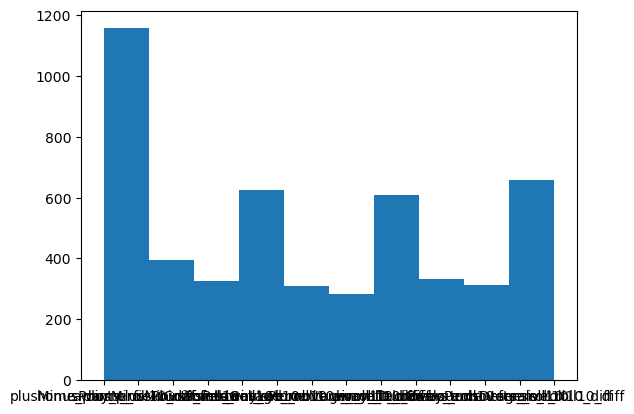

In [ ]:
fig50 = plt.hist(s50)
plt.show()

In [29]:
for ll in best_holder:
    ll = list(ll)
    pipe_g.fit(x_cv[ll], y_cv)
    print(pipe_g['gam'].accuracy(xh[ll],yh), pipe_g['gam'].loglikelihood(xh[ll],yh))

0.6226829268292683 -12921.325351175808
0.6225609756097561 -12921.115250850973
0.6226829268292683 -13030.40638942826
0.6230487804878049 -13070.608062517233
0.6292682926829268 -12816.224754135945
0.6225609756097561 -12920.97806416253
0.6218292682926829 -12824.6542239005
0.6217073170731707 -12859.479843954383
0.6217073170731707 -12910.425508229164
0.6223170731707317 -12951.27708120884
0.6213414634146341 -12853.7603539543
0.6198780487804878 -12893.000499741964
0.6204878048780488 -12825.049010254917


In [ ]:
#Go one by one changing an l(num) to s(n) to see any changes

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

pipe_g = Pipeline(steps=[
    #('poly', PolynomialFeatures(2)),
    ('scale', StandardScaler()),
    ('gam', LogisticGAM(
        l(0) + l(1) + l(2) + l(3) + l(4) + l(5) + 
        s(4) + s(5)# + s(0) + s(1) + s(2) + s(3)
        ).gridsearch())
])

#pipe_g.fit(xg_tr,yg_tr).grid

#print(gam.accuracy())

pipe_g['gam'].summary()
print(pipe_g['gam'].accuracy(xg_tr, yg_tr))

#fig, axs = plt.subplots(2, 2)
#titles = var_1st_4
'''
for i, ax in enumerate(axs):
    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, width=0.95)

    ax.plot(XX[:, i], pdep)
    ax.plot(XX[:, i], confi, c="r", ls="--")
    ax.set_title(titles[i])
'''

LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     24.3237
Link Function:                        LogitLink Log Likelihood:                                -10403.5996
Number of Samples:                        16400 AIC:                                            20855.8465
                                                AICc:                                            20855.928
                                                UBRE:                                               3.2729
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                     0.07
Feature Function                  Lam

/tmp/ipykernel_1422428/3623772497.py:16: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  pipe_g['gam'].summary()


'\nfor i, ax in enumerate(axs):\n    XX = gam.generate_X_grid(term=i)\n    pdep, confi = gam.partial_dependence(term=i, width=0.95)\n\n    ax.plot(XX[:, i], pdep)\n    ax.plot(XX[:, i], confi, c="r", ls="--")\n    ax.set_title(titles[i])\n'

In [ ]:
l_ary = [x for x in np.arange(0.3,0.9, 0.025)]

pipe_g = Pipeline(steps=[
    #('poly', PolynomialFeatures(2)),
    ('scale', StandardScaler()),
    ('gam', LogisticGAM(
        #s(0, lam=0.7) + s(1, lam=0.7) + s(2, lam=0.7) + s(3, lam=0.7) + s(4, lam=0.7) + s(5, lam=0.7) 
        #+ s(4) + s(5)# + s(0) + s(1) + s(2) + s(3)
        l(0) + l(1) + l(2) + l(3) + l(4) + l(5) + 
        s(4) + s(5), # + s(0) + s(1) + s(2) + s(3)
        ))
])

pipe_g.fit(xg_tr,yg_tr)
scores_dict = pipe_g['gam'].gridsearch(xg_tr, yg_tr, lam = l_ary, return_scores=True)

for model, score in scores_dict.items():
    print(f"Lambda for spline: {model.lam[1]}, Score: {score}")
print(pipe_g['gam'].accuracy(xg_tr,yg_tr))

#pipe_g['gam'].summary()
#print(pipe_g['gam'].accuracy(xg_tr, yg_tr))

#fig, axs = plt.subplots(2, 2)
#titles = var_1st_4
'''
for i, ax in enumerate(axs):
    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, width=0.95)

    ax.plot(XX[:, i], pdep)
    ax.plot(XX[:, i], confi, c="r", ls="--")
    ax.set_title(titles[i])
'''

  0% (0 of 25) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/pygam/links.py:137: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/pygam/pygam.py:631: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2
/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/pygam/links.py:121: RuntimeWarning: overflow encountered in exp
  elp = np.exp(lp)
/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/pygam/links.py:122: RuntimeWarning: invalid value encountered in divide
  return dist.levels * elp / (elp + 1)
/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/pygam/links.py:137: RuntimeWarning: overflow encountered in divide
  return dist.levels / (mu * 

Lambda for spline: [np.float64(0.9000000000000006)], Score: 3.2739835718229404
Lambda for spline: [np.float64(0.3)], Score: 3.2712656034324525
Lambda for spline: [np.float64(0.325)], Score: 3.2712577158236824
Lambda for spline: [np.float64(0.35000000000000003)], Score: 3.271250403371668
Lambda for spline: [np.float64(0.37500000000000006)], Score: 3.2712435946804828
Lambda for spline: [np.float64(0.4000000000000001)], Score: 3.2712372307447666
Lambda for spline: [np.float64(0.4250000000000001)], Score: 3.27123126232676
Lambda for spline: [np.float64(0.4500000000000001)], Score: 3.27122564795696
Lambda for spline: [np.float64(0.47500000000000014)], Score: 3.2712203524094967
Lambda for spline: [np.float64(0.5000000000000002)], Score: 3.271215345525274
Lambda for spline: [np.float64(0.5250000000000001)], Score: 3.2712106012935425
Lambda for spline: [np.float64(0.5500000000000003)], Score: 3.271206097128024
Lambda for spline: [np.float64(0.5750000000000002)], Score: 3.2712018132911203
Lambd

'\nfor i, ax in enumerate(axs):\n    XX = gam.generate_X_grid(term=i)\n    pdep, confi = gam.partial_dependence(term=i, width=0.95)\n\n    ax.plot(XX[:, i], pdep)\n    ax.plot(XX[:, i], confi, c="r", ls="--")\n    ax.set_title(titles[i])\n'

In [17]:
#gam.accuracy()
yg_tr.value_counts()

win
1    9417
0    6983
Name: count, dtype: int64

In [36]:
del l

In [6]:

pipe_g = Pipeline(steps=[
    #('poly', PolynomialFeatures(2)),
    ('scale', StandardScaler()),
    ('gam', LogisticGAM(
        s(0) + l(1) + l(2) + l(3) + l(4), max_iter=250, 
        ))
])


v0 = ['plusMinusPoints_roll10_diff', 'away_plusMinusPoints_roll10', 'home_fieldGoalsPercentage_roll10', 'fieldGoalsPercentage_roll10_diff', 'home_turnovers_roll10']
v1 = ['away_plusMinusPoints_roll10','plusMinusPoints_roll10_diff','home_fieldGoalsPercentage_roll10', 'fieldGoalsPercentage_roll10_diff', 'home_turnovers_roll10']
v2 = ['home_fieldGoalsPercentage_roll10','plusMinusPoints_roll10_diff', 'away_plusMinusPoints_roll10', 'fieldGoalsPercentage_roll10_diff', 'home_turnovers_roll10']
v3 = ['fieldGoalsPercentage_roll10_diff','plusMinusPoints_roll10_diff', 'away_plusMinusPoints_roll10', 'home_fieldGoalsPercentage_roll10', 'home_turnovers_roll10']
v4 = ['home_turnovers_roll10','plusMinusPoints_roll10_diff', 'away_plusMinusPoints_roll10', 'home_fieldGoalsPercentage_roll10', 'fieldGoalsPercentage_roll10_diff', ]

vtest = []
vtest.append(v0)
vtest.append(v1)
vtest.append(v2)
vtest.append(v3)
vtest.append(v4)



In [39]:
for i, var in enumerate(vtest):
    pipe_g.fit(x_cv[var], y_cv)
    print(i, pipe_g['gam'].accuracy(xh[var],yh), pipe_g['gam'].loglikelihood(xh[var], yh))

0 0.5290243902439025 -28569.937864473337


/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/pygam/links.py:137: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/pygam/pygam.py:631: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2
/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/pygam/links.py:121: RuntimeWarning: overflow encountered in exp
  elp = np.exp(lp)
/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/pygam/links.py:122: RuntimeWarning: invalid value encountered in divide
  return dist.levels * elp / (elp + 1)
/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/pygam/links.py:137: RuntimeWarning: overflow encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/home/mars/miniconda3/envs/erdos_ds_environment/lib/python3.

1 0.6131707317073171 -16162.158562750272
2 0.6226829268292683 -12956.688625896393
3 0.6228048780487805 -12943.084630884023
4 0.526829268292683 -23576.78380429609


In [35]:
type(x_cv['turnovers_roll10_diff'].iloc[0])
print(x_cv[v20].columns)

Index(['plusMinusPoints_roll10_diff', 'away_plusMinusPoints_roll10',
       'home_fieldGoalsPercentage_roll10', 'fieldGoalsPercentage_roll10_diff',
       'turnovers_roll10_diff', 'home_turnovers_roll10',
       'away_fieldGoalsPercentage_roll10', 'away_turnovers_roll10',
       'reboundsDefensive_roll10_diff', 'steals_roll10_diff'],
      dtype='str')


In [45]:
red = ['plusMinusPoints_roll10_diff',
       'home_fieldGoalsPercentage_roll10',
        'home_turnovers_roll10',
       'away_fieldGoalsPercentage_roll10', 'steals_roll10_diff']

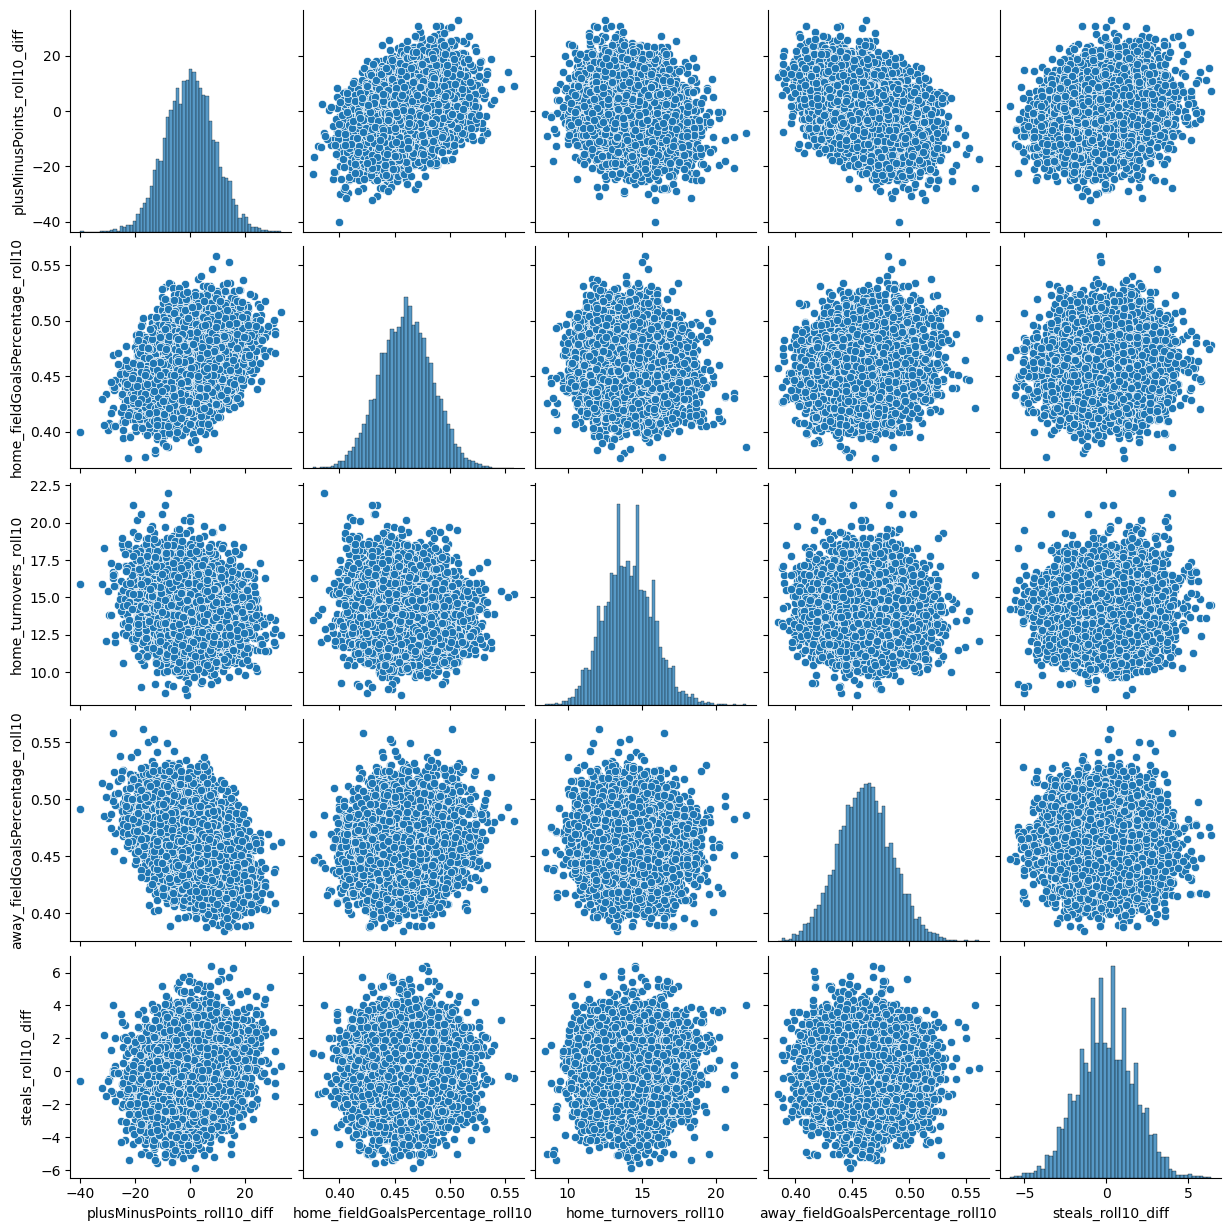

In [41]:
sns.pairplot(x_cv[red], vars=red)

In [96]:
from pygam import te
nsp = 20
'''
pipe_g = Pipeline(steps=[
    #('poly', PolynomialFeatures(2)),
    ('scale', StandardScaler()),
    ('gam', LogisticGAM(
        #s(0, lam=0.7) + s(1, lam=0.7) + s(2, lam=0.7) + s(3, lam=0.7) + s(4, lam=0.7) + s(5, lam=0.7) 
        #+ s(4) + s(5)# + s(0) + s(1) + s(2) + s(3)
        l(0) + s(1, n_splines=nsp) + s(2, n_splines=nsp) + s(3, n_splines=nsp) + s(4, n_splines=nsp) + 
        te(0,0) + te(0,1) + te(0,2) + te(0,3) + te(0,4) +
        te(1,1) + te(1,2) + te(1,3) + te(1,4) 
        #te(2,2) + te(2,3) + te(2,4) +
        #te(3,3) + te(3,4) + 
        #te(4,4) 
        , max_iter=250
        ))
])
'''
pipe_g = Pipeline(steps=[
    #('scale', StandardScaler()),
    ('gam', LogisticGAM(
        s(0, 100) + l(1) + l(2) + s(3) + l(4) + te(0,1), max_iter=300, 
        #s(0, 100) + l(1) + l(2) + s(3, 100) + l(4) + te(1,2) + te(1,4) + te(2,4) + te(3,4), max_iter=300, 
        ))
])
pipe_g.fit(x_cv[v3],y_cv)

#scores_dict = pipe_g['gam'].gridsearch(xh[v0], yh, lam = l_ary, return_scores=True)

#for model, score in scores_dict.items():
#    print(f"Lambda for spline: {model.lam[1]}, Score: {score}")

print(pipe_g['gam'].accuracy(xh[v3],yh))

0.6387872451646628


In [112]:
#Naive Bayes using roll10 variables that we would have access to before a prediction 
#Reg data set
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import roc_auc_score, precision_score
from sklearn.preprocessing import PolynomialFeatures

#Loop that iterates over each column in the above list, fits, and calculates the accuracy
#Only models/variables that yield results better than chance are reported

pipe_n = Pipeline(steps=[
    ('nb', GaussianNB())
])

pipe_n.fit(x_cv[varlist], y_cv)
y_pred = pipe_n.predict(xh[varlist])
acc    = 1.0*sum(y_pred==yh) / len(y_pred)
print(acc)



0.6293779404077365


In [111]:
#Naive Bayes using roll10 variables that we would have access to before a prediction 
#Reg data set
from sklearn.svm import SVC

#Loop that iterates over each column in the above list, fits, and calculates the accuracy
#Only models/variables that yield results better than chance are reported

pipe_n = Pipeline(steps=[
    ('scale', StandardScaler()),
    ('svc', SVC())
])

pipe_n.fit(x_cv[varlist], y_cv)
y_pred = pipe_n.predict(xh[varlist])
acc    = 1.0*sum(y_pred==yh) / len(y_pred)
print(acc)

0.6332984840564558


In [117]:
l_ary = [x for x in np.arange(0.1,0.9, 0.02)]
nsp = 25
pipe_g = Pipeline(steps=[
    #('poly', PolynomialFeatures(2)),
    #('scale', StandardScaler()),
    ('gam', LogisticGAM(
        s(0) + l(1) + l(2) + s(3) + l(4) + te(0,1), max_iter=300
        ))
])

pipe_g.fit(x_cv[v3],y_cv)

scores_dict = pipe_g['gam'].gridsearch(xh[v3], yh, lam = l_ary, return_scores=True)

for model, score in scores_dict.items():
    print(f"Lambda for spline: {model.lam[1]}, Score: {score}")

#print(pipe_g['gam'].accuracy(xh[v0],yh))

  0% (0 of 40) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  2% (1 of 40) |                         | Elapsed Time: 0:00:00 ETA:   0:00:22
  5% (2 of 40) |#                        | Elapsed Time: 0:00:01 ETA:   0:00:20
  7% (3 of 40) |#                        | Elapsed Time: 0:00:01 ETA:   0:00:21
 10% (4 of 40) |##                       | Elapsed Time: 0:00:02 ETA:   0:00:21
 12% (5 of 40) |###                      | Elapsed Time: 0:00:02 ETA:   0:00:20
 15% (6 of 40) |###                      | Elapsed Time: 0:00:03 ETA:   0:00:19
 17% (7 of 40) |####                     | Elapsed Time: 0:00:03 ETA:   0:00:17
 20% (8 of 40) |#####                    | Elapsed Time: 0:00:04 ETA:   0:00:17
 22% (9 of 40) |#####                    | Elapsed Time: 0:00:05 ETA:   0:00:18
 25% (10 of 40) |######                  | Elapsed Time: 0:00:07 ETA:   0:00:21
 27% (11 of 40) |######                  | Elapsed Time: 0:00:07 ETA:   0:00:19
 30% (12 of 40) |#######                

Lambda for spline: [np.float64(0.8800000000000001)], Score: 3.273964959877964
Lambda for spline: [np.float64(0.1)], Score: 3.270938181460133
Lambda for spline: [np.float64(0.12000000000000001)], Score: 3.270698664725112
Lambda for spline: [np.float64(0.14)], Score: 3.270491751869016
Lambda for spline: [np.float64(0.16000000000000003)], Score: 3.2703095137631655
Lambda for spline: [np.float64(0.18000000000000002)], Score: 3.270146661178352
Lambda for spline: [np.float64(0.2)], Score: 3.269999474466847
Lambda for spline: [np.float64(0.22000000000000003)], Score: 3.2698653323735
Lambda for spline: [np.float64(0.24000000000000002)], Score: 3.2697419497648608
Lambda for spline: [np.float64(0.26)], Score: 3.2696278620579435
Lambda for spline: [np.float64(0.28)], Score: 3.269521803204174
Lambda for spline: [np.float64(0.30000000000000004)], Score: 3.2694227528089073
Lambda for spline: [np.float64(0.32000000000000006)], Score: 3.269329875742718
Lambda for spline: [np.float64(0.3400000000000001

In [33]:
#PyGAM initialization 
import scipy.sparse

def to_array(self):
    return self.toarray()

scipy.sparse.spmatrix.A = property(to_array)

# Generalized Additive Model (GAM):
# LinearGAM fits y ≈ sum_j f_j(x_j), where each f_j is a smooth curve.
from pygam import LinearGAM, s

In [34]:
# Cross-validation splitter:
# KFold divides your dataset into K disjoint “folds”.
# You train on K-1 folds and validate on the remaining fold, repeating K times.
# Use shuffle=True and a fixed random_state for reproducible splits.
from sklearn.model_selection import KFold

# Evaluation metric:
# root_mean_squared_error (RMSE) measures typical prediction error size.
# It is in the same units as your target. Lower is better.
# RMSE is sensitive to outliers because it squares errors.
from sklearn.metrics import root_mean_squared_error

# Baseline linear model:
# LinearRegression fits a straight-line relationship (ordinary least squares).
# Good simple baseline.
from sklearn.linear_model import LinearRegression


# Hacky solution to a dependency problem for pyGAM https://github.com/dswah/pyGAM/issues/357 
import scipy.sparse

def to_array(self):
    return self.toarray()

scipy.sparse.spmatrix.A = property(to_array)

# Generalized Additive Model (GAM):
# LinearGAM fits y ≈ sum_j f_j(x_j), where each f_j is a smooth curve.
from pygam import LinearGAM, s


kf = KFold(n_splits=5, shuffle=True, random_state=42)

#array for holding validation scores.  First column will be for linear model, second for GAM.
rmse_scores = np.full((5, 2), np.nan)

X = df_train[features]
y = df_train[target]

for i, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Re-initialize a new GAM each time
    linear = LinearRegression()
    linear.fit(X_train, y_train)
    linear_pred = linear.predict(X_val)
    linear_rmse = root_mean_squared_error(y_val, linear_pred)
    rmse_scores[i,0] = linear_rmse

    gam = LinearGAM(s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7), lam = 100)
    gam.fit(X_train, y_train)    
    gam_pred = gam.predict(X_val)
    gam_rmse = root_mean_squared_error(y_val, gam_pred)
    rmse_scores[i,1] = gam_rmse

print(f'RMSEs on each fold: \n {np.round(rmse_scores,2)}')
print(f'Mean RMSE: {np.round(np.mean(rmse_scores, axis = 0),2)}')
print(f'Standard deviation: {np.round(np.std(rmse_scores, axis = 0),2)}')


NameError: name 'df_train' is not defined

In [ ]:
df_r.columns

Index(['gameId', 'gameDate', 'season', 'teamId', 'teamName', 'opponentTeamId',
       'opponentTeamName', 'home', 'win', 'teamScore', 'opponentScore',
       'fieldGoalsPercentage', 'threePointersPercentage',
       'freeThrowsPercentage', 'reboundsOffensive', 'reboundsDefensive',
       'assists', 'turnovers', 'steals', 'blocks', 'plusMinusPoints',
       'rest_days', 'b2b', 'teamScore_roll10', 'fieldGoalsPercentage_roll10',
       'threePointersPercentage_roll10', 'freeThrowsPercentage_roll10',
       'reboundsOffensive_roll10', 'reboundsDefensive_roll10',
       'assists_roll10', 'turnovers_roll10', 'steals_roll10', 'blocks_roll10',
       'plusMinusPoints_roll10', 'win_roll10'],
      dtype='str')

In [ ]:
df_m.columns

Index(['gameId', 'gameDate', 'season', 'home_teamId', 'home_teamName',
       'home_rest_days', 'home_b2b', 'win', 'home_teamScore_roll10',
       'home_fieldGoalsPercentage_roll10',
       'home_threePointersPercentage_roll10',
       'home_freeThrowsPercentage_roll10', 'home_reboundsOffensive_roll10',
       'home_reboundsDefensive_roll10', 'home_assists_roll10',
       'home_turnovers_roll10', 'home_steals_roll10', 'home_blocks_roll10',
       'home_plusMinusPoints_roll10', 'home_win_roll10', 'away_teamId',
       'away_teamName', 'away_rest_days', 'away_b2b', 'away_teamScore_roll10',
       'away_fieldGoalsPercentage_roll10',
       'away_threePointersPercentage_roll10',
       'away_freeThrowsPercentage_roll10', 'away_reboundsOffensive_roll10',
       'away_reboundsDefensive_roll10', 'away_assists_roll10',
       'away_turnovers_roll10', 'away_steals_roll10', 'away_blocks_roll10',
       'away_plusMinusPoints_roll10', 'away_win_roll10',
       'teamScore_roll10_diff', 'fieldGoalsP

In [ ]:
#Naive Bayes using roll10 variables that we would have access to before a prediction 
#RP data set
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import roc_auc_score, precision_score

ll_r = ['home', 'fieldGoalsPercentage', 'threePointersPercentage',
       'freeThrowsPercentage', 'reboundsOffensive', 'reboundsDefensive',
       'assists', 'turnovers', 'steals', 'blocks', 'plusMinusPoints',
       'rest_days', 'b2b', 'teamScore_roll10', 'fieldGoalsPercentage_roll10',
       'threePointersPercentage_roll10', 'freeThrowsPercentage_roll10',
       'reboundsOffensive_roll10', 'reboundsDefensive_roll10',
       'assists_roll10', 'turnovers_roll10', 'steals_roll10', 'blocks_roll10',
       'plusMinusPoints_roll10', 'win_roll10','win']

df_rrp = df_roll_RP[ll_roll_rp].dropna()
y_rrp  = df_rrp['win']
r_dic = {}

#Loop that iterates over each column in the above list, fits, and calculates the accuracy
#Only models/variables that yield results better than chance are reported
for col in ll_roll_rp:
    if col == 'win':continue
    kf       = KFold(n_splits=5)
    stat_ary = np.zeros((3, 5))
    x_tr, x_te, y_tr, y_te = train_test_split(df_rrp[col], y_rrp, random_state=17, test_size=0.2)
    
    for i, (train_ix, test_ix) in enumerate(kf.split(x_tr)):
       xr = x_tr.iloc[train_ix].values.reshape(-1,1)
       yr = y_tr.iloc[train_ix]
       xh = x_tr.iloc[test_ix].values.reshape(-1,1)
       yh = y_tr.iloc[test_ix]
       nb = GaussianNB()
       nb.fit(xr, yr)

       y_pred = nb.predict(xh)
       acc    = 1.0*sum(y_pred==yh) / len(y_pred)
       prob   = nb.predict_proba(xh)
       roc    = roc_auc_score(yh, prob[:,1])
       prec   = precision_score(yh, y_pred)

       stat_ary[0][i] = acc
       stat_ary[1][i] = roc
       stat_ary[2][i] = prec

    if (stat_ary[0].mean() > 0.5 and stat_ary[1].mean() > 0.5 and stat_ary[2].mean() > 0.5):
       rstr = '%s Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = %.3f(%.3f),%.3f(%.3f), %.3f(%.3f)'%(
          col, stat_ary[0].mean(),stat_ary[0].std(), stat_ary[1].mean(),stat_ary[1].std(),stat_ary[2].mean(),stat_ary[2].std())
       acc_m = stat_ary[0].mean()
       r_dic[rstr] = acc_m

#Sorts the results by descending mean accuracty and prints the results
r_sorted = {k : v for k, v in sorted(r_dic.items(), key = lambda item: item[1], reverse=True)}

print('Roll10 Regular + Playoffs Results')
for key, value in r_sorted.items():
   print(key)


Roll10 Regular + Playoffs Results
plusMinusPoints Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 1.000(0.000),1.000(0.000), 1.000(0.000)
fieldGoalsPercentage Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.687(0.004),0.760(0.004), 0.693(0.007)
reboundsDefensive Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.648(0.005),0.703(0.007), 0.668(0.007)
threePointersPercentage Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.642(0.005),0.693(0.005), 0.650(0.008)
assists Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.622(0.006),0.672(0.006), 0.646(0.004)
plusMinusPoints_roll10 Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.585(0.007),0.619(0.006), 0.578(0.006)
win_roll10 Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.578(0.004),0.607(0.006), 0.566(0.003)
home Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.577(0.008),0.577(0.008), 0.579(0.007)
blocks Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.565(0.005),0.594(0.004), 0.592(0.006)
steals Mean Acc(STD), Mean ROC(STD), Mean Prec(STD

In [ ]:
#Naive Bayes using roll10 variables that we would have access to before a prediction 
#Reg data set
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import roc_auc_score, precision_score

ll_roll_rg = ['home', 'fieldGoalsPercentage', 'threePointersPercentage',
       'freeThrowsPercentage', 'reboundsOffensive', 'reboundsDefensive',
       'assists', 'turnovers', 'steals', 'blocks', 'plusMinusPoints',
       'rest_days', 'b2b', 'teamScore_roll10', 'fieldGoalsPercentage_roll10',
       'threePointersPercentage_roll10', 'freeThrowsPercentage_roll10',
       'reboundsOffensive_roll10', 'reboundsDefensive_roll10',
       'assists_roll10', 'turnovers_roll10', 'steals_roll10', 'blocks_roll10',
       'plusMinusPoints_roll10', 'win_roll10','win']

df_rrg = df_roll_Rg[ll_roll_rg].dropna()
y_rrg  = df_rrg['win']
r_dic = {}

#Loop that iterates over each column in the above list, fits, and calculates the accuracy
#Only models/variables that yield results better than chance are reported
for col in ll_roll_rg:
    if col == 'win':continue
    kf       = KFold(n_splits=5)
    stat_ary = np.zeros((3, 5))
    x_tr, x_te, y_tr, y_te = train_test_split(df_rrg[col], y_rrg, random_state=17, test_size=0.2)
    
    for i, (train_ix, test_ix) in enumerate(kf.split(x_tr)):
       xr = x_tr.iloc[train_ix].values.reshape(-1,1)
       yr = y_tr.iloc[train_ix]
       xh = x_tr.iloc[test_ix].values.reshape(-1,1)
       yh = y_tr.iloc[test_ix]
       nb = GaussianNB()
       nb.fit(xr, yr)

       y_pred = nb.predict(xh)
       acc    = 1.0*sum(y_pred==yh) / len(y_pred)
       prob   = nb.predict_proba(xh)
       roc    = roc_auc_score(yh, prob[:,1])
       prec   = precision_score(yh, y_pred)

       stat_ary[0][i] = acc
       stat_ary[1][i] = roc
       stat_ary[2][i] = prec

    if (stat_ary[0].mean() > 0.5 and stat_ary[1].mean() > 0.5 and stat_ary[2].mean() > 0.5):
       rstr = '%s Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = %.3f(%.3f),%.3f(%.3f), %.3f(%.3f)'%(
          col, stat_ary[0].mean(),stat_ary[0].std(), stat_ary[1].mean(),stat_ary[1].std(),stat_ary[2].mean(),stat_ary[2].std())
       acc_m = stat_ary[0].mean()
       r_dic[rstr] = acc_m

#Sorts the results by descending mean accuracty and prints the results
r_sorted = {k : v for k, v in sorted(r_dic.items(), key = lambda item: item[1], reverse=True)}

print('Roll10 Regular Results')
for key, value in r_sorted.items():
   print(key)


Roll10 Regular Results
plusMinusPoints Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 1.000(0.000),1.000(0.000), 1.000(0.000)
fieldGoalsPercentage Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.689(0.002),0.760(0.002), 0.696(0.005)
reboundsDefensive Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.649(0.005),0.704(0.004), 0.667(0.005)
threePointersPercentage Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.640(0.005),0.689(0.006), 0.648(0.005)
assists Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.623(0.006),0.673(0.006), 0.644(0.006)
plusMinusPoints_roll10 Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.589(0.005),0.622(0.009), 0.582(0.006)
win_roll10 Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.584(0.005),0.613(0.008), 0.572(0.005)
home Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.574(0.008),0.574(0.009), 0.576(0.009)
blocks Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.564(0.004),0.594(0.006), 0.591(0.007)
steals Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.552(0

In [ ]:
#Naive Bayes using match variables that we would have access to before a prediction 
#RP data set
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import roc_auc_score, precision_score

ll_match_rp = ['home_rest_days', 'home_b2b', 'win', 'home_teamScore_roll10',
       'home_fieldGoalsPercentage_roll10',
       'home_threePointersPercentage_roll10',
       'home_freeThrowsPercentage_roll10', 'home_reboundsOffensive_roll10',
       'home_reboundsDefensive_roll10', 'home_assists_roll10',
       'home_turnovers_roll10', 'home_steals_roll10', 'home_blocks_roll10',
       'home_plusMinusPoints_roll10', 'home_win_roll10', 'away_rest_days', 
       'away_b2b', 'away_teamScore_roll10', 'away_fieldGoalsPercentage_roll10',
       'away_threePointersPercentage_roll10',
       'away_freeThrowsPercentage_roll10', 'away_reboundsOffensive_roll10',
       'away_reboundsDefensive_roll10', 'away_assists_roll10',
       'away_turnovers_roll10', 'away_steals_roll10', 'away_blocks_roll10',
       'away_plusMinusPoints_roll10', 'away_win_roll10',
       'teamScore_roll10_diff', 'fieldGoalsPercentage_roll10_diff',
       'threePointersPercentage_roll10_diff',
       'freeThrowsPercentage_roll10_diff', 'reboundsOffensive_roll10_diff',
       'reboundsDefensive_roll10_diff', 'assists_roll10_diff',
       'turnovers_roll10_diff', 'steals_roll10_diff', 'blocks_roll10_diff',
       'plusMinusPoints_roll10_diff', 'win_roll10_diff', 'rest_days_diff',
       'b2b_diff']

df_mrp = df_match_RP[ll_match_rp].dropna()
y_mrp  = df_mrp['win']
r_dic = {}

#Loop that iterates over each column in the above list, fits, and calculates the accuracy
#Only models/variables that yield results better than chance are reported
for col in ll_match_rp:
    if col == 'win':continue
    kf       = KFold(n_splits=5)
    stat_ary = np.zeros((3, 5))
    x_tr, x_te, y_tr, y_te = train_test_split(df_mrp[col], y_mrp, random_state=17, test_size=0.2)
    
    for i, (train_ix, test_ix) in enumerate(kf.split(x_tr)):
       xr = x_tr.iloc[train_ix].values.reshape(-1,1)
       yr = y_tr.iloc[train_ix]
       xh = x_tr.iloc[test_ix].values.reshape(-1,1)
       yh = y_tr.iloc[test_ix]
       nb = GaussianNB()
       nb.fit(xr, yr)

       y_pred = nb.predict(xh)
       acc    = 1.0*sum(y_pred==yh) / len(y_pred)
       prob   = nb.predict_proba(xh)
       roc    = roc_auc_score(yh, prob[:,1])
       prec   = precision_score(yh, y_pred)

       stat_ary[0][i] = acc
       stat_ary[1][i] = roc
       stat_ary[2][i] = prec

    if (stat_ary[0].mean() > 0.5 and stat_ary[1].mean() > 0.5 and stat_ary[2].mean() > 0.5):
       rstr = '%s Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = %.3f(%.3f),%.3f(%.3f), %.3f(%.3f)'%(
          col, stat_ary[0].mean(),stat_ary[0].std(), stat_ary[1].mean(),stat_ary[1].std(),stat_ary[2].mean(),stat_ary[2].std())
       acc_m = stat_ary[0].mean()
       r_dic[rstr] = acc_m

#Sorts the results by descending mean accuracty and prints the results
r_sorted = {k : v for k, v in sorted(r_dic.items(), key = lambda item: item[1], reverse=True)}

print('Match Regular + Playoffs Results')
for key, value in r_sorted.items():
   print(key)


Match Regular + Playoffs Results
plusMinusPoints_roll10_diff Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.632(0.010),0.671(0.006), 0.650(0.010)
win_roll10_diff Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.627(0.011),0.658(0.009), 0.645(0.012)
home_plusMinusPoints_roll10 Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.614(0.007),0.629(0.007), 0.624(0.007)
home_win_roll10 Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.609(0.008),0.616(0.005), 0.622(0.007)
fieldGoalsPercentage_roll10_diff Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.599(0.008),0.606(0.013), 0.609(0.007)
away_plusMinusPoints_roll10 Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.595(0.006),0.610(0.009), 0.610(0.007)
teamScore_roll10_diff Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.592(0.008),0.599(0.011), 0.603(0.008)
away_win_roll10 Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.591(0.008),0.604(0.007), 0.610(0.009)
away_fieldGoalsPercentage_roll10 Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.58

In [ ]:
#Naive Bayes using match variables that we would have access to before a prediction 
#Reg data set
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import roc_auc_score, precision_score

ll_match_rg = ['home_rest_days', 'home_b2b', 'win', 'home_teamScore_roll10',
       'home_fieldGoalsPercentage_roll10',
       'home_threePointersPercentage_roll10',
       'home_freeThrowsPercentage_roll10', 'home_reboundsOffensive_roll10',
       'home_reboundsDefensive_roll10', 'home_assists_roll10',
       'home_turnovers_roll10', 'home_steals_roll10', 'home_blocks_roll10',
       'home_plusMinusPoints_roll10', 'home_win_roll10', 'away_rest_days', 
       'away_b2b', 'away_teamScore_roll10', 'away_fieldGoalsPercentage_roll10',
       'away_threePointersPercentage_roll10',
       'away_freeThrowsPercentage_roll10', 'away_reboundsOffensive_roll10',
       'away_reboundsDefensive_roll10', 'away_assists_roll10',
       'away_turnovers_roll10', 'away_steals_roll10', 'away_blocks_roll10',
       'away_plusMinusPoints_roll10', 'away_win_roll10',
       'teamScore_roll10_diff', 'fieldGoalsPercentage_roll10_diff',
       'threePointersPercentage_roll10_diff',
       'freeThrowsPercentage_roll10_diff', 'reboundsOffensive_roll10_diff',
       'reboundsDefensive_roll10_diff', 'assists_roll10_diff',
       'turnovers_roll10_diff', 'steals_roll10_diff', 'blocks_roll10_diff',
       'plusMinusPoints_roll10_diff', 'win_roll10_diff', 'rest_days_diff',
       'b2b_diff']

df_mrg = df_match_RP[ll_match_rg].dropna()
y_mrg  = df_mrg['win']
r_dic = {}

#Loop that iterates over each column in the above list, fits, and calculates the accuracy
#Only models/variables that yield results better than chance are reported
for col in ll_match_rg:
    if col == 'win':continue
    kf       = KFold(n_splits=5)
    stat_ary = np.zeros((3, 5))
    x_tr, x_te, y_tr, y_te = train_test_split(df_mrg[col], y_mrg, random_state=17, test_size=0.2)
    
    for i, (train_ix, test_ix) in enumerate(kf.split(x_tr)):
       xr = x_tr.iloc[train_ix].values.reshape(-1,1)
       yr = y_tr.iloc[train_ix]
       xh = x_tr.iloc[test_ix].values.reshape(-1,1)
       yh = y_tr.iloc[test_ix]
       nb = GaussianNB()
       nb.fit(xr, yr)

       y_pred = nb.predict(xh)
       acc    = 1.0*sum(y_pred==yh) / len(y_pred)
       prob   = nb.predict_proba(xh)
       roc    = roc_auc_score(yh, prob[:,1])
       prec   = precision_score(yh, y_pred)

       stat_ary[0][i] = acc
       stat_ary[1][i] = roc
       stat_ary[2][i] = prec

    if (stat_ary[0].mean() > 0.5 and stat_ary[1].mean() > 0.5 and stat_ary[2].mean() > 0.5):
       rstr = '%s Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = %.3f(%.3f),%.3f(%.3f), %.3f(%.3f)'%(
          col, stat_ary[0].mean(),stat_ary[0].std(), stat_ary[1].mean(),stat_ary[1].std(),stat_ary[2].mean(),stat_ary[2].std())
       acc_m = stat_ary[0].mean()
       r_dic[rstr] = acc_m

#Sorts the results by descending mean accuracty and prints the results
r_sorted = {k : v for k, v in sorted(r_dic.items(), key = lambda item: item[1], reverse=True)}

print('Match Regular Results')
for key, value in r_sorted.items():
   print(key)


Match Regular Results
plusMinusPoints_roll10_diff Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.632(0.010),0.671(0.006), 0.650(0.010)
win_roll10_diff Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.627(0.011),0.658(0.009), 0.645(0.012)
home_plusMinusPoints_roll10 Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.614(0.007),0.629(0.007), 0.624(0.007)
home_win_roll10 Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.609(0.008),0.616(0.005), 0.622(0.007)
fieldGoalsPercentage_roll10_diff Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.599(0.008),0.606(0.013), 0.609(0.007)
away_plusMinusPoints_roll10 Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.595(0.006),0.610(0.009), 0.610(0.007)
teamScore_roll10_diff Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.592(0.008),0.599(0.011), 0.603(0.008)
away_win_roll10 Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.591(0.008),0.604(0.007), 0.610(0.009)
away_fieldGoalsPercentage_roll10 Mean Acc(STD), Mean ROC(STD), Mean Prec(STD) = 0.583(0.010),0.

Naive Bayes Base Model Conclusions

In general, there is not a significant differece between the regular season games data set and the regular season + playoff data set when taking into accout the means and standard deviations of the statistic tests.

A base model of just predicting if a team will win based upon the whether the game is a home game is 57.7 +- 0.8 %
A base model of just predicting if a team will win based upon the mean field goal percentage is      68.7 +- 0.4 %

In [ ]:
#Naive Bayes using roll10 variables that we would have access to before a prediction 
#Train and test are now time ordered
from sklearn.naive_bayes import GaussianNB
from sklearn. metrics import roc_auc_score, precision_score

ll = ['home', 'threePointersPercentage_roll10', 'freeThrowsPercentage_roll10',
       'reboundsOffensive_roll10', 'reboundsDefensive_roll10',
       'assists_roll10', 'turnovers_roll10', 'steals_roll10', 'blocks_roll10',
       'plusMinusPoints_roll10', 'win_roll10']

df_roll_sort = df_roll.sort_values(by=['gameDate']).dropna()
n80 = int(len(df_roll_sort)*0.8)

#Loop that iterates over each column in the above list, fits, and calculates the accuracy
#Only models/variables that yield results better than chance are reported
for col in ll:
    df = df_roll_sort[col]
    y = df_roll_sort['win']
    
    x_tr, x_te, y_tr, y_te = df[:n80], df[n80:], y[:n80], y[n80:]
    nb = GaussianNB()
    nb.fit(x_tr.values.reshape(-1,1), y_tr)
    y_pred = nb.predict(x_tr.values.reshape(-1,1))
    acc_train = 1.0*sum(y_pred==y_tr) / len(y_pred)

    y_pred2 = nb.predict(x_te.values.reshape(-1,1))
    acc_test = 1.0*sum(y_pred2==y_te) / len(y_pred2)
    prob_test = nb.predict_proba(x_te.values.reshape(-1,1))
    roc = roc_auc_score(y_te, prob_test[:,1])
    prec = precision_score(y_te, y_pred2)

    if (acc_train > 0.5 and prec > 0.5 and roc > 0.5):
       print('%s Train(Test) acc., roc, prec. = %.3f,%.3f, %.3f, %.3f'%(col, acc_train, acc_test, roc, prec))

home Train(Test) acc., roc, prec. = 0.579,0.551, 0.551, 0.551
threePointersPercentage_roll10 Train(Test) acc., roc, prec. = 0.532,0.530, 0.547, 0.525
freeThrowsPercentage_roll10 Train(Test) acc., roc, prec. = 0.520,0.517, 0.526, 0.514
reboundsOffensive_roll10 Train(Test) acc., roc, prec. = 0.514,0.504, 0.504, 0.506
reboundsDefensive_roll10 Train(Test) acc., roc, prec. = 0.522,0.535, 0.555, 0.544
assists_roll10 Train(Test) acc., roc, prec. = 0.530,0.511, 0.528, 0.507
turnovers_roll10 Train(Test) acc., roc, prec. = 0.516,0.530, 0.564, 0.520
steals_roll10 Train(Test) acc., roc, prec. = 0.517,0.521, 0.529, 0.520
blocks_roll10 Train(Test) acc., roc, prec. = 0.518,0.520, 0.529, 0.522
plusMinusPoints_roll10 Train(Test) acc., roc, prec. = 0.578,0.592, 0.629, 0.586
win_roll10 Train(Test) acc., roc, prec. = 0.570,0.586, 0.616, 0.570


In [ ]:
#Naive Bayes using match variables that we would have access to before a prediction 
#Train and test are now time ordered
from sklearn.naive_bayes import GaussianNB

ll = ['home_teamScore_roll10', 'home_fieldGoalsPercentage_roll10',
       'home_threePointersPercentage_roll10',
       'home_freeThrowsPercentage_roll10', 'home_reboundsOffensive_roll10',
       'home_reboundsDefensive_roll10', 'home_assists_roll10',
       'home_turnovers_roll10', 'home_steals_roll10', 'home_blocks_roll10',
       'home_plusMinusPoints_roll10', 'home_win_roll10', 'away_teamScore_roll10',
       'away_fieldGoalsPercentage_roll10',
       'away_threePointersPercentage_roll10',
       'away_freeThrowsPercentage_roll10', 'away_reboundsOffensive_roll10',
       'away_reboundsDefensive_roll10', 'away_assists_roll10',
       'away_turnovers_roll10', 'away_steals_roll10', 'away_blocks_roll10',
       'away_plusMinusPoints_roll10', 'away_win_roll10',
       'teamScore_roll10_diff', 'fieldGoalsPercentage_roll10_diff',
       'threePointersPercentage_roll10_diff',
       'freeThrowsPercentage_roll10_diff', 'reboundsOffensive_roll10_diff',
       'reboundsDefensive_roll10_diff', 'assists_roll10_diff',
       'turnovers_roll10_diff', 'steals_roll10_diff', 'blocks_roll10_diff',
       'plusMinusPoints_roll10_diff', 'win_roll10_diff']

df_match_sort = df_match.sort_values(by=['gameDate']).dropna()
n80 = int(len(df_match_sort)*0.8)

#Loop that iterates over each column in the above list, fits, and calculates the accuracy
#Only models/variables that yield results better than 0.6 are reported
for col in ll:
    df = df_match_sort[col]
    y = df_match_sort['win']
    
    x_tr, x_te, y_tr, y_te = df[:n80], df[n80:], y[:n80], y[n80:]
    nb = GaussianNB()
    nb.fit(x_tr.values.reshape(-1,1), y_tr)
    y_pred = nb.predict(x_tr.values.reshape(-1,1))
    acc_train = 1.0*sum(y_pred==y_tr) / len(y_pred)

    y_pred2 = nb.predict(x_te.values.reshape(-1,1))
    acc_test = 1.0*sum(y_pred2==y_te) / len(y_pred2)
    prob_test = nb.predict_proba(x_te.values.reshape(-1,1))
    roc = roc_auc_score(y_te, prob_test[:,1])
    prec = precision_score(y_te, y_pred2)

    if (acc_train > 0.6 and prec > 0.5 and roc > 0.5):
       print('%s Train(Test) acc., roc, prec. = %.3f,%.3f, %.3f, %.3f'%(col, acc_train, acc_test, roc, prec))

home_plusMinusPoints_roll10 Train(Test) acc., roc, prec. = 0.613,0.607, 0.639, 0.606
home_win_roll10 Train(Test) acc., roc, prec. = 0.606,0.603, 0.625, 0.601
plusMinusPoints_roll10_diff Train(Test) acc., roc, prec. = 0.628,0.634, 0.687, 0.634
win_roll10_diff Train(Test) acc., roc, prec. = 0.622,0.625, 0.669, 0.627
